# PetTriage — Data Merge & Validation

**Inputs:**
- `data/raw/synthetic/*.csv` — 11 LLM-generated category files (200 rows each)
- `data/processed/dogs_cats_labeled.csv` — 147 seed rows from Dataset 1

**Output:** `data/processed/training_data.csv` — the final training dataset

**Validation checks:**
1. Schema: all files have exactly 23 expected columns
2. Value integrity: no unexpected values in categorical columns
3. Binary flag consistency: symptom text matches Yes/No flags
4. Class balance: are categories balanced enough to train on?

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

SYNTHETIC_DIR = '../data/raw/synthetic'
SEED_PATH = '../data/processed/dogs_cats_labeled.csv'

# Expected schema
EXPECTED_COLS = [
    'Animal_Type', 'Breed', 'Age', 'Gender', 'Weight',
    'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
    'Duration', 'Appetite_Loss', 'Vomiting', 'Diarrhea',
    'Coughing', 'Labored_Breathing', 'Lameness', 'Skin_Lesions',
    'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature',
    'Heart_Rate', 'Disease_Category', 'Urgency'
]

VALID_URGENCY = {'Emergency', 'Monitor', 'Okay'}
VALID_ANIMAL = {'Dog', 'Cat'}
VALID_BINARY = {'Yes', 'No'}
BINARY_COLS = [
    'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing',
    'Labored_Breathing', 'Lameness', 'Skin_Lesions',
    'Nasal_Discharge', 'Eye_Discharge'
]

## Check 1: Schema Validation

Every file must have exactly the 23 expected columns in the correct order.

In [2]:
files = sorted(os.listdir(SYNTHETIC_DIR))
schema_issues = []

for f in files:
    df = pd.read_csv(os.path.join(SYNTHETIC_DIR, f))
    if list(df.columns) != EXPECTED_COLS:
        missing = set(EXPECTED_COLS) - set(df.columns)
        extra = set(df.columns) - set(EXPECTED_COLS)
        schema_issues.append(f'{f}: missing={missing}, extra={extra}')

if schema_issues:
    print('SCHEMA ISSUES FOUND:')
    for issue in schema_issues:
        print(' ', issue)
else:
    print('Schema check PASSED — all 11 files have correct columns.')

Schema check PASSED — all 11 files have correct columns.


## Check 2: Value Integrity

Categorical columns must only contain expected values.
Numeric columns must be within realistic ranges.

In [4]:
all_dfs = []
for f in files:
    df = pd.read_csv(os.path.join(SYNTHETIC_DIR, f))
    df['_source_file'] = f
    all_dfs.append(df)

synthetic = pd.concat(all_dfs, ignore_index=True)
print(f'Total synthetic rows loaded: {len(synthetic)}')
print()

# Check Urgency
bad_urgency = synthetic[~synthetic['Urgency'].isin(VALID_URGENCY)]
print(f'Invalid Urgency values: {len(bad_urgency)}')
if len(bad_urgency) > 0:
    print(bad_urgency[['_source_file', 'Urgency']].value_counts())

# Check Animal_Type
bad_animal = synthetic[~synthetic['Animal_Type'].isin(VALID_ANIMAL)]
print(f'Invalid Animal_Type values: {len(bad_animal)}')
if len(bad_animal) > 0:
    print(bad_animal[['_source_file', 'Animal_Type']].value_counts())

# Check binary columns
for col in BINARY_COLS:
    bad = synthetic[~synthetic[col].isin(VALID_BINARY)]
    if len(bad) > 0:
        print(f'Invalid values in {col}: {bad[col].unique()}')

# Check numeric ranges
print()
print('Temperature range:', synthetic['Body_Temperature'].min(), '-', synthetic['Body_Temperature'].max())
print('Heart rate range: ', synthetic['Heart_Rate'].min(), '-', synthetic['Heart_Rate'].max())
print('Age range:        ', synthetic['Age'].min(), '-', synthetic['Age'].max())
print('Weight range:     ', synthetic['Weight'].min(), '-', synthetic['Weight'].max())

Total synthetic rows loaded: 2200

Invalid Urgency values: 0
Invalid Animal_Type values: 0

Temperature range: 38.1 - 42.0
Heart rate range:  60 - 260
Age range:         1 - 15
Weight range:      2.0 - 57.5


## Check 3: Binary Flag Consistency

If Symptom_1-4 says 'Vomiting', then Vomiting = Yes must follow.
Inconsistent rows are a data quality problem — we'll count them here.

In [5]:
# Map from symptom text → binary column name
SYMPTOM_TO_FLAG = {
    'Vomiting': 'Vomiting',
    'Diarrhea': 'Diarrhea',
    'Coughing': 'Coughing',
    'Labored Breathing': 'Labored_Breathing',
    'Lameness': 'Lameness',
    'Limping': 'Lameness',
    'Skin Lesions': 'Skin_Lesions',
    'Excessive Scratching': 'Skin_Lesions',
    'Nasal Discharge': 'Nasal_Discharge',
    'Eye Discharge': 'Eye_Discharge',
    'Loss of Appetite': 'Appetite_Loss',
}

inconsistent_rows = []

for idx, row in synthetic.iterrows():
    symptom_text = [
        str(row['Symptom_1']), str(row['Symptom_2']),
        str(row['Symptom_3']), str(row['Symptom_4'])
    ]
    for symptom, flag_col in SYMPTOM_TO_FLAG.items():
        if symptom in symptom_text and row[flag_col] != 'Yes':
            inconsistent_rows.append({
                'row': idx,
                'file': row['_source_file'],
                'symptom': symptom,
                'flag_col': flag_col,
                'flag_value': row[flag_col]
            })

print(f'Inconsistent rows found: {len(inconsistent_rows)}')

if inconsistent_rows:
    inc_df = pd.DataFrame(inconsistent_rows)
    print('\nBreakdown by file:')
    print(inc_df['file'].value_counts())
    print('\nBreakdown by symptom:')
    print(inc_df['symptom'].value_counts())
    print(f'\nThis is {len(inconsistent_rows)/len(synthetic)*100:.1f}% of all rows.')
    print('Decision: auto-fix these rows by setting the flag to Yes.')

Inconsistent rows found: 0


In [6]:
# AUTO-FIX: set binary flag = Yes where symptom text says it should be
fixed_count = 0

for idx, row in synthetic.iterrows():
    symptom_text = [
        str(row['Symptom_1']), str(row['Symptom_2']),
        str(row['Symptom_3']), str(row['Symptom_4'])
    ]
    for symptom, flag_col in SYMPTOM_TO_FLAG.items():
        if symptom in symptom_text and synthetic.at[idx, flag_col] != 'Yes':
            synthetic.at[idx, flag_col] = 'Yes'
            fixed_count += 1

print(f'Auto-fixed {fixed_count} flag inconsistencies.')

Auto-fixed 0 flag inconsistencies.


## Check 4: Class Balance

Are categories balanced? Urgency distribution reasonable?

In [7]:
# Drop the source file tracking column before final merge
synthetic_clean = synthetic.drop(columns=['_source_file'])

print('=== CATEGORY DISTRIBUTION (synthetic only) ===')
cat_counts = synthetic_clean['Disease_Category'].value_counts()
print(cat_counts)

print('\n=== URGENCY DISTRIBUTION (overall) ===')
print(synthetic_clean['Urgency'].value_counts())
print(f"\nEmergency ratio: {(synthetic_clean['Urgency']=='Emergency').mean():.1%}")
print(f"Monitor ratio:   {(synthetic_clean['Urgency']=='Monitor').mean():.1%}")
print(f"Okay ratio:      {(synthetic_clean['Urgency']=='Okay').mean():.1%}")

print('\n=== URGENCY PER CATEGORY ===')
print(pd.crosstab(synthetic_clean['Disease_Category'], synthetic_clean['Urgency']))

=== CATEGORY DISTRIBUTION (synthetic only) ===
Disease_Category
Bacterial / Parasitic    200
Dental / Oral            200
Endocrine / Metabolic    200
Eye / Ear                200
Gastrointestinal         200
Musculoskeletal          200
Renal / Urinary          200
Respiratory              200
Skin / Fungal            200
Trauma / Poisoning       200
Viral Systemic           200
Name: count, dtype: int64

=== URGENCY DISTRIBUTION (overall) ===
Urgency
Monitor      1040
Okay          590
Emergency     570
Name: count, dtype: int64

Emergency ratio: 25.9%
Monitor ratio:   47.3%
Okay ratio:      26.8%

=== URGENCY PER CATEGORY ===
Urgency                Emergency  Monitor  Okay
Disease_Category                               
Bacterial / Parasitic         50      110    40
Dental / Oral                 40       90    70
Endocrine / Metabolic         30      120    50
Eye / Ear                     30      100    70
Gastrointestinal              60       90    50
Musculoskeletal            

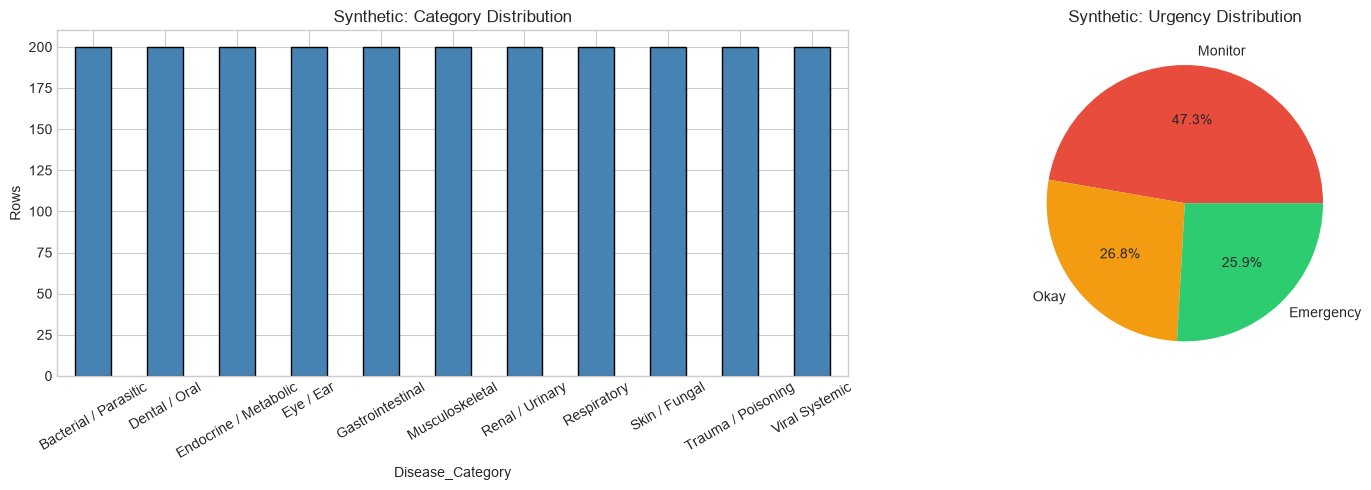

In [8]:
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Synthetic: Category Distribution')
axes[0].set_ylabel('Rows')
axes[0].tick_params(axis='x', rotation=30)

synthetic_clean['Urgency'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#e74c3c', '#f39c12', '#2ecc71']
)
axes[1].set_title('Synthetic: Urgency Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Merge: Synthetic + Seed Data

The seed data (147 rows from Dataset 1) only has 9 categories and no Urgency column.
We add it carefully — aligning columns and marking its origin.

In [9]:
seed = pd.read_csv(SEED_PATH)
print('Seed columns:', list(seed.columns))
print('Seed shape:', seed.shape)

# Seed data doesn't have Urgency — check if it exists
print('\nHas Urgency column:', 'Urgency' in seed.columns)

Seed columns: ['Animal_Type', 'Breed', 'Age', 'Gender', 'Weight', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Duration', 'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness', 'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature', 'Heart_Rate', 'Disease_Prediction', 'Disease_Category']
Seed shape: (147, 23)

Has Urgency column: False


In [10]:
# The seed data has extra columns we don't need for training
# and is missing the Urgency column.
# Strategy: use seed data only if it has Urgency, otherwise skip merging it
# and rely solely on our synthetic data which is cleaner and labeled.

# Check what columns the seed has vs what we need
seed_has = set(seed.columns)
need = set(EXPECTED_COLS)
print('In seed but not needed:', seed_has - need)
print('Needed but not in seed:', need - seed_has)

In seed but not needed: {'Disease_Prediction'}
Needed but not in seed: {'Urgency'}


In [11]:
# Decision: since seed data lacks Urgency (our key label for Model B),
# we use synthetic data as our primary training set.
# The seed data is preserved as reference but not merged into training.
# This can be revisited when we have real urgency labels from users.

training_data = synthetic_clean.copy()

print(f'Final training dataset shape: {training_data.shape}')
print(f'Categories: {training_data["Disease_Category"].nunique()}')
print(f'Rows per category:')
print(training_data['Disease_Category'].value_counts())

Final training dataset shape: (2200, 23)
Categories: 11
Rows per category:
Disease_Category
Bacterial / Parasitic    200
Dental / Oral            200
Endocrine / Metabolic    200
Eye / Ear                200
Gastrointestinal         200
Musculoskeletal          200
Renal / Urinary          200
Respiratory              200
Skin / Fungal            200
Trauma / Poisoning       200
Viral Systemic           200
Name: count, dtype: int64


## Final Check: Missing Values

In [12]:
missing = training_data.isnull().sum()
if missing.any():
    print('Missing values found:')
    print(missing[missing > 0])
else:
    print('No missing values — dataset is clean.')

print(f'\nData types:')
print(training_data.dtypes)

Missing values found:
Symptom_2      21
Symptom_3     791
Symptom_4    1666
dtype: int64

Data types:
Animal_Type           object
Breed                 object
Age                    int64
Gender                object
Weight               float64
Symptom_1             object
Symptom_2             object
Symptom_3             object
Symptom_4             object
Duration              object
Appetite_Loss         object
Vomiting              object
Diarrhea              object
Coughing              object
Labored_Breathing     object
Lameness              object
Skin_Lesions          object
Nasal_Discharge       object
Eye_Discharge         object
Body_Temperature     float64
Heart_Rate             int64
Disease_Category      object
Urgency               object
dtype: object


## Save Final Training Dataset

In [13]:
output_path = '../data/processed/training_data.csv'
training_data.to_csv(output_path, index=False)

print(f'Saved to: {output_path}')
print(f'Shape: {training_data.shape}')
print(f'\nSample rows:')
training_data.sample(5)

Saved to: ../data/processed/training_data.csv
Shape: (2200, 23)

Sample rows:


,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Category,Urgency
2118,Dog,Border Collie,1,Male,15.0,Fever,Lethargy,Loss of Appetite,Eye Discharge,2 months,...,No,No,No,No,No,Yes,38.7,94,Viral Systemic,Okay
466,Cat,Maine Coon,10,Male,6.7,Excessive Thirst,Increased Urination,Weight Loss,Lethargy,1 month,...,No,No,No,No,No,No,38.5,170,Endocrine / Metabolic,Emergency
1503,Dog,Poodle,2,Female,28.5,Sneezing,Nasal Discharge,NaN,NaN,2 days,...,No,No,No,No,Yes,No,39.4,132,Respiratory,Monitor
1348,Dog,Husky,14,Female,17.9,Difficulty Urinating,Increased Urination,NaN,NaN,3 days,...,No,No,No,No,No,No,39.0,113,Renal / Urinary,Monitor
651,Cat,Domestic Longhair,15,Female,5.7,Ear Scratching,Head Shaking,NaN,NaN,3 weeks,...,No,No,No,No,No,No,38.3,125,Eye / Ear,Okay


---
## Summary

After running this notebook, `training_data.csv` is ready for model training.

**What's in it:**
- 2,200 synthetic rows across 11 disease categories
- Both condition labels (`Disease_Category`) and urgency labels (`Urgency`)
- Cleaned, validated, flag-consistent data

**Next:** `04_feature_engineering.ipynb` — transform raw columns into model-ready features.